<a href="https://colab.research.google.com/github/cesarjuarez72/a3_cesar_juarez_python_refresher/blob/main/a3_cesar_juarez_python_refresher_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Ai


# Assignment 3: Python Programming Refresher  
# Notebook: Lesson_3_assignment.ipynb

### Project Overview:

In this assignment, we build a simple, working Library Management System in Python. It serves as a practical refresher on core programming topics you need for data analytics and AI:

*   Working with core data types and list operations
*   Writing functions, user input prompts, and loops with index tracking
*   Saving and loading data using text files, Python's pickle module, and an SQLite database
*   Fetching live web data using an API
*   Handling errors gracefully with try/except blocks so the program doesn't crash on bad inputs


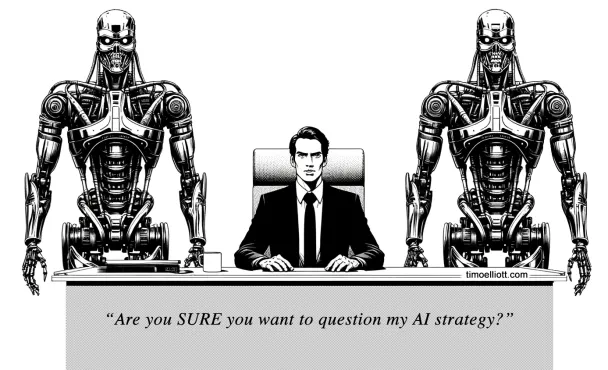

In [14]:
from IPython.display import Image
Image('question_ai_strategy_terminator.jpg', width=600)

# Setup: Libraries and Packages

School Notes:



*   **requests:** A third-party package used to talk to websites and web APIs. The ! tells Colab or Jupyter to run the command directly in the environment terminal so the library is installed and ready to use.

*   **pickle:** A built-in Python tool used to convert Python objects (like lists or dictionaries) directly into binary files on your computer and reload them later.

*   **sqlite3:** A lightweight, built-in SQL database engine. It lets us create and manage real database tables stored directly in a local file without needing a separate database server.
  

In [1]:
# Install external dependencies (pre-installed in standard Colab environments)
!pip install requests

# Standard library modules
import pickle
import sqlite3

# Third-party HTTP library
import requests

# 1. Data Types and Variables

School Notes:

**What this does:** Stores four key details about a single book using Python's standard data types:



*   **book_title:** A string (str), used for text.
*   **book_quantity:** An integer (int), used for whole numbers.

*   **book_price:** A float, used for decimal values.  
*   **is_available:** A boolean (bool), which can only be True or False.


**Key Technique:** We print them using an f-string (f"..."), which lets us plug variables directly into curly brackets {} inside the text string.  

In [2]:
# 1. Data Types and Variables
book_title = "Python Programming"
book_quantity = 5
book_price = 29.99
is_available = True

print(f"Book: {book_title}, Quantity: {book_quantity}, Price: ${book_price}, Available: {is_available}")

Book: Python Programming, Quantity: 5, Price: $29.99, Available: True


# 2. Lists & Adding Items

School Notes:

**The Goal:** Add two new books to the existing list.  

**Key Vocabulary & Methods**:

*   Lists are mutable, meaning you can add, change, or delete items inside them without recreating the whole list.
*   **.append():** Adds an item to the very end of the list.

*   **.insert(index, item):** Puts an item at a specific location. Using index 0 places the new book at the very beginning, sliding all the other books one spot to the right.

In [3]:
# 2. Lists
books = ["Python Basics", "Advanced Python", "Data Science with Python"]

# TODO: Add two more books to the list
books.append("Machine Learning with Python")
books.insert(0, "Automate the Boring Stuff")

print("Updated book list:", books)

Updated book list: ['Automate the Boring Stuff', 'Python Basics', 'Advanced Python', 'Data Science with Python', 'Machine Learning with Python']


# 3. Loops and range()

**School Notes:**

**The Goal:** Print each book in the list along with its position number (index) using a for loop.

**How It Works:**

*   **len(books)** counts how many books are in the list.  
*   **range()** generates a sequence of numbers starting at 0.

*   Because Python uses zero-based indexing (the first item is at index 0, the second is at index 1, etc.), the variable i steps through every index number.
*   Inside the loop, **books[i]** grabs the actual title sitting at that position.

In [4]:
# 3. Loops and range()
print("\nAvailable books:")

# TODO: Use a for loop and range() to print books with their indices
for i in range(len(books)):
    print(f"Index {i}: {books[i]}")


Available books:
Index 0: Automate the Boring Stuff
Index 1: Python Basics
Index 2: Advanced Python
Index 3: Data Science with Python
Index 4: Machine Learning with Python


# 4. User Input

School Notes:

**The Goal:** Let the user type a new title in the console and add it straight to the inventory.

**How It Works:**

*   **input()** pauses the program and waits for the user to type something and press Enter.

*   It always captures what was typed as text (a string), which we store in the new_book variable and immediately **.append()** into the books list.

In [12]:
# 4. User Input
new_book = input("Enter a new book title: ").strip()

# Check for empty submission
while not new_book:
    print("Book title cannot be blank.")
    new_book = input("Enter a valid book title: ").strip()

books.append(new_book)
print("Updated book list:", books)

Enter a new book title: 
Book title cannot be blank.
Enter a valid book title: The Wild Boys
Updated book list: ['Automate the Boring Stuff', 'Python Basics', 'Data Science with Python', 'Machine Learning with Python', 'Aura', 'The Wild Boys']


# 5. Functions and Conditional Statements

School Notes:

**The Goal:** Build a reusable function called check_availability() that tells us if a book is in our inventory.  

**How It Works:**

*   The function takes a parameter called **book_name**.
*   We use Python's built-in **in** keyword, which scans through the books list.

*   If a match is found, it returns **True**. If not, the else branch triggers and returns **False**.

In [6]:
# 5. Functions and Conditional Statements
def check_availability(book_name):
    # TODO: Check if the book is in the list and return True if available, False otherwise
    if book_name in books:
        return True
    else:
        return False

# Test the function
print(f"Is 'Python Basics' available? {check_availability('Python Basics')}")

Is 'Python Basics' available? True


# 6. File I/O (Reading and Writing Text Files)

School Notes:

**The Goal:** Save the book titles into a .txt file, and write a new function to read them back into Python.  

**Key Vocabulary & Techniques:**


*   **Context Manager (with open(...)):** This automatically closes the file the second the indented code is finished. It prevents files from getting locked or corrupted if something goes wrong.

*   **.strip():** Text files save each book on a new line using a hidden newline character (\n). .strip() trims that off so we get clean book titles back.

*   **Error Handling (try/except):** We wrap the file-reading logic in a try/except block. If the file does not exist, Python catches the FileNotFoundError and prints a clear message instead of crashing the notebook.

In [7]:
# 6. File I/O
def save_books_to_file(filename):
    with open(filename, 'w') as f:
        for book in books:
            f.write(f"{book}\n")

# TODO: Implement a function to read books from a file
def read_books_from_file(filename):
    try:
        with open(filename, 'r') as f:
            # Read every line and clean off the hidden newline (\n) characters
            file_books = [line.strip() for line in f.readlines()]
            print("Books successfully read from text file.")
            return file_books
    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return []

# Test file I/O
save_books_to_file("books.txt")
!cat books.txt  # Colab/Jupyter command to display file contents on screen

loaded_books = read_books_from_file("books.txt")
print("Parsed books from file:", loaded_books)

Automate the Boring Stuff
Python Basics
Advanced Python
Data Science with Python
Machine Learning with Python
Aura
Books successfully read from text file.
Parsed books from file: ['Automate the Boring Stuff', 'Python Basics', 'Advanced Python', 'Data Science with Python', 'Machine Learning with Python', 'Aura']


# 7. Pickle for Serialization

School Notes:

**The Goal:** Save and reload our Python list as a binary file using Python's pickle module.  

**Key Vocabulary & Techniques:**

*   **Serialization:** Taking a Python object in memory (like our list) and converting it into a raw byte stream so it can be saved to disk.

*   **Binary Mode ('rb'):** Because pickle works with binary data rather than plain text, we must open the file with 'rb' (read binary).

*   **pickle.load(f):** Reads the binary stream and instantly reconstructs it back into a working Python list.

*   **Error Handling:** We catch both FileNotFoundError (missing file) and pickle.UnpicklingError (corrupted or unreadable file).
      

In [8]:
# 7. Pickle for serialization
def save_books_pickle(filename):
    with open(filename, 'wb') as f:
        pickle.dump(books, f)

# TODO: Implement a function to load books using pickle
def load_books_pickle(filename):
    try:
        with open(filename, 'rb') as f:
            loaded_books = pickle.load(f)
            return loaded_books
    except FileNotFoundError:
        print(f"Error: The pickle file '{filename}' was not found.")
        return []
    except pickle.UnpicklingError:
        print(f"Error: The file '{filename}' is corrupted or not a valid pickle file.")
        return []

# Test pickle functions
save_books_pickle("books.pkl")
print("Books loaded from pickle:", load_books_pickle("books.pkl"))

Books loaded from pickle: ['Automate the Boring Stuff', 'Python Basics', 'Advanced Python', 'Data Science with Python', 'Machine Learning with Python', 'Aura']


# 8. SQLite Database Interaction

School Notes:

**The Goal:** Insert new book records (with a title and quantity) into a local SQLite relational database table.  

**Key Vocabulary & Techniques:**



*   **conn = sqlite3.connect(...):** Opens a connection to the database file.  

*   **cursor:** The worker object that lets us execute SQL commands against the database.

*   **Parameterization (VALUES (?, ?)):** Instead of gluing the book title directly into the SQL string, we use question-mark placeholders (?, ?). This is a crucial security best practice that prevents broken queries and protects against SQL injection attacks.

*   **conn.commit():** Commits the transaction to make sure the inserted record is actually saved to disk.

*   **finally block:** Guarantees that conn.close() is always executed at the end, even if an error happens during the insert. This keeps the database file from getting locked.

In [9]:
# 8. SQLite Database Interaction
def create_books_table():
    conn = sqlite3.connect('library.db')
    cursor = conn.cursor()
    cursor.execute('''CREATE TABLE IF NOT EXISTS books
                      (id INTEGER PRIMARY KEY, title TEXT, quantity INTEGER)''')
    conn.commit()
    conn.close()

# TODO: Implement a function to add a book to the SQLite database
def add_book_to_db(title, quantity):
    conn = None
    try:
        conn = sqlite3.connect('library.db')
        cursor = conn.cursor()

        # Use ? placeholders to safely pass values into the SQL table
        cursor.execute("INSERT INTO books (title, quantity) VALUES (?, ?)", (title, quantity))
        conn.commit()
        print(f"Successfully added '{title}' (Quantity: {quantity}) to the database.")

    except sqlite3.Error as e:
        print(f"SQLite Database error: {e}")

    finally:
        # Always close the database connection
        if conn:
            conn.close()

# Test database functions
create_books_table()
add_book_to_db("Python for Beginners", 10)

Successfully added 'Python for Beginners' (Quantity: 10) to the database.


# 9. Web API Interaction (GitHub API)

School Notes:

**The Goal:** Fetch live public repository data from the GitHub API using an HTTP request.  

**Key Vocabulary & Techniques:**

*   **API (Application Programming Interface):** A way for our code to ask another service (in this case, GitHub) for data over the internet.

*   **requests.get():** Sends an HTTP request to the target web address, passing search options (query parameters) like language and star rating.
*   **response.json():** Converts the raw data returned by GitHub into standard Python dictionaries and lists so we can easily read it.


*   **List Comprehension ([repo['name'] for repo in ...]):** A clean, one-line loop that extracts just the name of each top repository.

In [10]:
# 9. Web API Interaction (GitHub API)
def get_python_repos():
    url = "https://api.github.com/search/repositories"
    params = {"q": "language:python", "sort": "stars", "order": "desc"}
    response = requests.get(url, params=params)
    data = response.json()
    return [repo['name'] for repo in data['items'][:5]]

# Test API function
print("Top 5 Python repositories on GitHub:", get_python_repos())

print("\nLibrary Management System operations completed.")

Top 5 Python repositories on GitHub: ['public-apis', 'free-programming-books', 'system-design-primer', 'awesome-python', 'project-based-learning']

Library Management System operations completed.


# Bonus: Removing Books from Inventory

**School Notes:**

**The Goal:** Add a clean way to remove books by title, fulfilling the optional extension suggested in the assignment guide.  

**Key Vocabulary & Techniques:**

*   **.remove():** Finds the matching item in the list and deletes it.

*   **Error Handling (ValueError):** If you try to remove a title that isn't actually in the list, Python normally crashes with a ValueError. We catch that error and print a friendly notice so the rest of the program keeps running smoothly.

In [11]:
# Bonus: Remove book functionality
def remove_book(book_name):
    try:
        books.remove(book_name)
        print(f"'{book_name}' has been successfully removed from inventory.")
    except ValueError:
        print(f"Notice: '{book_name}' was not found in the inventory.")

# Test removing an existing book
remove_book("Advanced Python")
print("Inventory after removal:", books)

# Test removing a book that does not exist
remove_book("Non-Existent Book")

'Advanced Python' has been successfully removed from inventory.
Inventory after removal: ['Automate the Boring Stuff', 'Python Basics', 'Data Science with Python', 'Machine Learning with Python', 'Aura']
Notice: 'Non-Existent Book' was not found in the inventory.


# Bonus 2: Interactive Command-Line Interface (CLI)

**School Notes:**

**The Goal:** Unify the standalone functions built across the assignment into an interactive menu that lets a user interact with the inventory dynamically.  

**Key Concepts:**

**Event Loop (while True):** Keeps the program running indefinitely until the user explicitly selects the exit option, which triggers break to stop the loop.

**Menu Dispatching (if/elif/else):** Maps numeric user choices directly to specific operations (viewing with indices, searching via check_availability, appending, or removing).  

**Input Sanitation (.strip()):** Strips accidental whitespace from user choices and titles so trailing spaces don't disrupt searches or store dirty data.

In [13]:
# Bonus 2: Interactive CLI Menu

def run_library_cli():
    print("\n--- Welcome to the Library Management System ---")

    while True:
        print("\nPlease select an option:")
        print("1. View Current Inventory")
        print("2. Search Book Availability")
        print("3. Add a Book to Inventory")
        print("4. Remove a Book from Inventory")
        print("5. Exit System")

        choice = input("Enter choice (1-5): ").strip()

        if choice == '1':
            print("\n--- Current Inventory ---")
            if not books:
                print("The inventory is currently empty.")
            else:
                for i in range(len(books)):
                    print(f"Index {i}: {books[i]}")

        elif choice == '2':
            query = input("\nEnter the title to search: ").strip()
            if query:
                found = check_availability(query)
                if found:
                    print(f"Result: '{query}' is currently IN STOCK.")
                else:
                    print(f"Result: '{query}' is NOT AVAILABLE in our inventory.")
            else:
                print("Search query cannot be empty.")

        elif choice == '3':
            new_title = input("\nEnter the title to add: ").strip()
            if new_title:
                books.append(new_title)
                print(f"Success: '{new_title}' has been added to inventory.")
            else:
                print("Title cannot be blank.")

        elif choice == '4':
            remove_title = input("\nEnter the title to remove: ").strip()
            if remove_title:
                remove_book(remove_title)
            else:
                print("Title cannot be blank.")

        elif choice == '5':
            print("\nExiting Library Management System. Session closed.")
            break

        else:
            print("Invalid selection. Please enter a valid menu number (1 to 5).")

# Launch the interactive menu
run_library_cli()


--- Welcome to the Library Management System ---

Please select an option:
1. View Current Inventory
2. Search Book Availability
3. Add a Book to Inventory
4. Remove a Book from Inventory
5. Exit System
Enter choice (1-5): 1

--- Current Inventory ---
Index 0: Automate the Boring Stuff
Index 1: Python Basics
Index 2: Data Science with Python
Index 3: Machine Learning with Python
Index 4: Aura
Index 5: The Wild Boys

Please select an option:
1. View Current Inventory
2. Search Book Availability
3. Add a Book to Inventory
4. Remove a Book from Inventory
5. Exit System
Enter choice (1-5): 2

Enter the title to search: The Wild Boys
Result: 'The Wild Boys' is currently IN STOCK.

Please select an option:
1. View Current Inventory
2. Search Book Availability
3. Add a Book to Inventory
4. Remove a Book from Inventory
5. Exit System
Enter choice (1-5): 3

Enter the title to add: 1984
Success: '1984' has been added to inventory.

Please select an option:
1. View Current Inventory
2. Search Bo